# Classification - Data Science Portfolio - Mai Bui

We are implementing decision trees from scratch to classify fish species using the Kaggle dataset: https://www.kaggle.com/datasets/taweilo/fish-species-sampling-weight-and-height-data

This is to see if we can distinguish fish species with only weight and length (and their ratio)

**Dataset:** Fish Species Sampling Weight and Height Data https://www.kaggle.com/datasets/taweilo/fish-species-sampling-weight-and-height-data 

**Target variable:** Species of the fish (9 classes, fairly balanced with 415–480 samples each)

**Features:** length, weight and the weight-to-length ratio (w_l_ratio)

**Techniques applied:** Decision tree classifier implemented from scratch (Gini impurity, recursive splitting), pre-pruning by tuning max_depth, and a comparison with scikit-learn's DecisionTreeClassifier

A decision tree classifies a sample by recursively splitting the data on feature thresholds. At each node it picks the split that gives the lowest weighted Gini impurity, and each leaf predicts the majority class.

In this notebook, I will:

* Explore the data to see how well the species separate by length and weight
* Implement a decision tree classifier from scratch (Gini impurity, best-split search, recursive tree building, feature importances)
* Tune max_depth to control overfitting (best depth = 11), then evaluate on a held-out 20% test set with a classification report and confusion matrix
* Compare the from-scratch tree (93.5% test accuracy) with scikit-learn's tree (93.75%)
* Identify which features matter most (weight 0.57, length 0.30, w_l_ratio 0.13) and which species are confused (*Otolithoides biauritus* and *Setipinna taty*)

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

# Exploratory Data analysis

In [2]:
df = pd.read_csv("datasets/classification_dataset.csv")
df

,species,length,weight,w_l_ratio
0,Anabas testudineus,10.66,3.45,0.32
1,Anabas testudineus,6.91,3.27,0.47
2,Anabas testudineus,8.38,3.46,0.41
3,Anabas testudineus,7.57,3.36,0.44
4,Anabas testudineus,10.83,3.38,0.31
...,...,...,...,...
4075,Sillaginopsis panijus,30.56,6.12,0.20
4076,Sillaginopsis panijus,29.66,6.11,0.21
4077,Sillaginopsis panijus,32.81,6.25,0.19
4078,Sillaginopsis panijus,29.78,6.11,0.21


In [3]:
df["species"].value_counts()

species
Setipinna taty            480
Anabas testudineus        476
Pethia conchonius         475
Otolithoides biauritus    468
Polynemus paradiseus      458
Sillaginopsis panijus     455
Otolithoides pama         435
Puntius lateristriga      418
Coilia dussumieri         415
Name: count, dtype: int64

In [4]:
print('\nMissing values:', df.isnull().sum().sum())


Missing values: 0


The dataset is well-balanced, with between 415 and 480 samples per species, and contains no missing values. This means no imputation is needed and class imbalance is unlikely to bias the model.


In [5]:
# Summary statistics per species — shows whether features are discriminative
df.groupby('species')[['length', 'weight', 'w_l_ratio']].mean().round(3)

,length,weight,w_l_ratio
species,,,
Anabas testudineus,8.179,3.271,0.406
Coilia dussumieri,24.346,2.748,0.113
Otolithoides biauritus,18.550,3.198,0.173
Otolithoides pama,21.800,3.850,0.177
Pethia conchonius,9.605,4.585,0.486
Polynemus paradiseus,12.947,3.990,0.313
Puntius lateristriga,13.072,2.633,0.203
Setipinna taty,17.812,3.102,0.174
Sillaginopsis panijus,31.067,6.143,0.198


/var/folders/p0/hrndsk2d7jzbhfc3__sry99r0000gn/T/ipykernel_20751/4110538195.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['species'] = y


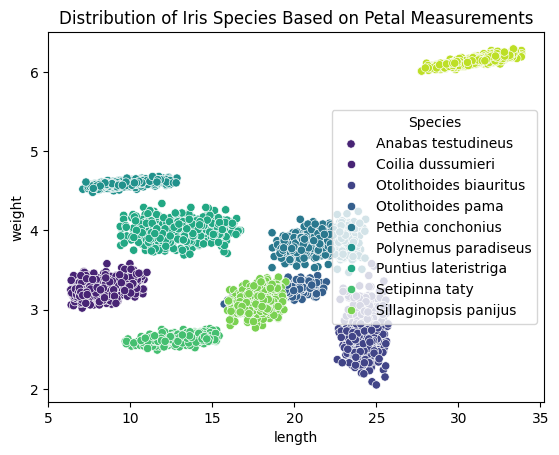

In [6]:
# Convert the last two features (petal length and width) to a DataFrame
feature_names = df.columns[1:3] # This captures 'petal length (cm)' and 'petal width (cm)'

X = df[feature_names]
y = df['species']


# Add the target to the DataFrame for easier plotting
X['species'] = y

# Scatter plot for petal dimensions using seaborn for automatic legend handling
sns.scatterplot(data=X, x='length', y='weight', hue='species', palette='viridis')

plt.title('Distribution of Iris Species Based on Petal Measurements')
plt.legend(title='Species', labels=list(df['species'].unique()))
plt.show()


The species seem to seperate mostly well by weight and length, with only some overlap between the Otolithoides biauritus and Setipinna taty, which might make them a bit harder to classify.

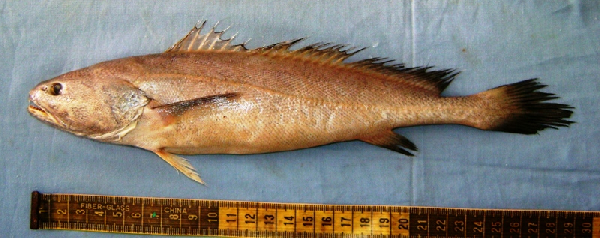 Otolithoides biauritus

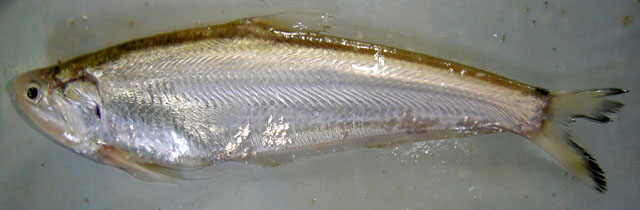 Setipinna taty

# Preprocessing

In [7]:
# Encode string labels as integers so the tree can work with them
label_names = sorted(df['species'].unique())          # alphabetical, stable order
label_to_int = {name: i for i, name in enumerate(label_names)}
int_to_label = {i: name for name, i in label_to_int.items()}

print('Label encoding:')
for name, idx in label_to_int.items():
    print(f'  {idx}: {name}')

Label encoding:
  0: Anabas testudineus
  1: Coilia dussumieri
  2: Otolithoides biauritus
  3: Otolithoides pama
  4: Pethia conchonius
  5: Polynemus paradiseus
  6: Puntius lateristriga
  7: Setipinna taty
  8: Sillaginopsis panijus


In [8]:
# Build feature matrix X and label vector y
feature_cols = ['length', 'weight', 'w_l_ratio']
X = df[feature_cols].to_numpy(dtype=float)
y = df['species'].map(label_to_int).to_numpy(dtype=int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')

Training set : 3264 samples
Test set     : 816 samples


# Manual decision tree

## setting up the decision tree

Decision Tree Implementation

A decision tree works by recursively partitioning the training data. At each node:
1. We search every feature and every possible split threshold
2. We choose the split that minimises Gini impurity in the resulting children
3. We recurse on each child until a stopping condition is met (max depth, or all samples have the same label)
4. At a leaf, we predict the majority class

Gini impurity of a node with $K$ classes is:
$$G = 1 - \sum_{k=1}^{K} p_k^2$$
where $p_k$ is the proportion of class $k$ at that node. A pure node (all one class) has $G = 0$.

In [9]:
# Compute the Gini impurity
def gini_impurity(y):
    n = len(y)
    if n == 0:
        return 0.0
    counts = np.bincount(y)          # count occurrences of each class
    probs = counts / n               # class proportions
    return 1.0 - np.sum(probs ** 2)


def weighted_gini(y_left, y_right):
    """
    Weighted average Gini impurity of a candidate split.
    
    The split quality is the size-weighted mean of the two children's Gini scores.
    A lower value means a cleaner, more useful split.
    """
    n = len(y_left) + len(y_right)
    return (len(y_left) / n) * gini_impurity(y_left) + \
           (len(y_right) / n) * gini_impurity(y_right)

# Find the feature and threshold that minimise weighted Gini impurity.
def best_split(X, y):
    best_feature, best_threshold, best_gini = None, None, float('inf')
    n_features = X.shape[1]

    for feature_idx in range(n_features):
        col = X[:, feature_idx]
        # Candidate thresholds: midpoints between consecutive sorted unique values
        unique_vals = np.unique(col)

        thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2
        for threshold in thresholds:
            left_mask = col <= threshold
            right_mask = ~left_mask
            # Skip degenerate splits where one child would be empty
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
            gini = weighted_gini(y[left_mask], y[right_mask])
            if gini < best_gini:
                best_gini = gini
                best_feature = feature_idx
                best_threshold = threshold

    return best_feature, best_threshold, best_gini

In [10]:
class DecisionTreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, prediction=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.prediction = prediction
        # Stats attached during fit (no separate annotation pass needed)
        self.n_samples = 0
        self.gini = 0.0
        self.class_counts = None

    def is_leaf(self):
        return self.prediction is not None


class manualDecisionTreeClassifier:
    """
    Decision Tree classifier implemented from scratch using Gini impurity.

    Parameters
    ----------
    max_depth : int or None
        Maximum depth of the tree. None = grow until leaves are pure.
    min_samples_split : int
        Minimum number of samples required to attempt a split.
    """

    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.feature_importances_ = None
        self._n_classes = None  # stored during fit for class_counts


    #  Training 
    def fit(self, X, y):
        """Build the tree and compute feature importances."""
        n_features = X.shape[1]
        self._n_classes = len(np.unique(y))

        # Must exist BEFORE _build, which adds to it at every split
        self._importance_accumulator = np.zeros(n_features)

        self.root = self._build(X, y, depth=0)

        total = self._importance_accumulator.sum()
        self.feature_importances_ = (
            self._importance_accumulator / total if total > 0
            else self._importance_accumulator
        )
        return self

    def _build(self, X, y, depth):
        """
        Recursively build a subtree, attaching node statistics inline
        so no separate annotation pass is required for plotting.
        """
        n_samples = len(y)
        node_gini = gini_impurity(y)
        node_class_counts = np.bincount(y, minlength=self._n_classes)

        # Stopping conditions → leaf
        if (len(np.unique(y)) == 1
                or (self.max_depth is not None and depth >= self.max_depth)
                or n_samples < self.min_samples_split):
            node = DecisionTreeNode(prediction=self._majority_class(y))
            node.n_samples = n_samples
            node.gini = round(node_gini, 4)
            node.class_counts = node_class_counts
            return node

        # Find best split
        feature, threshold, split_gini = best_split(X, y)

        if feature is None:          # no valid split found
            node = DecisionTreeNode(prediction=self._majority_class(y))
            node.n_samples = n_samples
            node.gini = round(node_gini, 4)
            node.class_counts = node_class_counts
            return node

        # Feature importance 
        gini_reduction = (node_gini - split_gini) * n_samples
        self._importance_accumulator[feature] += gini_reduction

        # Partition and recurse 
        left_mask = X[:, feature] <= threshold
        left_child  = self._build(X[left_mask], y[ left_mask], depth + 1)
        right_child = self._build(X[~left_mask], y[~left_mask], depth + 1)

        node = DecisionTreeNode(
            feature=feature, threshold=threshold,
            left=left_child, right=right_child
        )
        node.n_samples = n_samples
        node.gini = round(node_gini, 4)
        node.class_counts = node_class_counts
        return node

    @staticmethod
    def _majority_class(y):
        return int(np.argmax(np.bincount(y)))

    #  Prediction    
    def predict(self, X):
        return np.array([self._predict_one(row, self.root) for row in X])

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.prediction
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

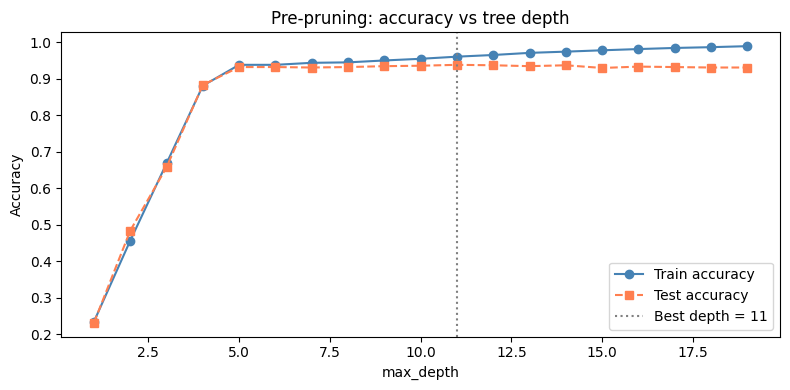

Best max_depth by test accuracy: 11


In [11]:
depths = range(1, 20)
train_accs, test_accs = [], []
 
for d in depths:
    clf = manualDecisionTreeClassifier(max_depth=d)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))
 
plt.figure(figsize=(8, 4))
plt.plot(depths, train_accs, "o-", label="Train accuracy", color="steelblue")
plt.plot(depths, test_accs, "s--", label="Test accuracy", color="coral")
plt.axvline(x=test_accs.index(max(test_accs)) + 1, color="gray",
            linestyle=":", label=f"Best depth = {test_accs.index(max(test_accs)) + 1}")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Pre-pruning: accuracy vs tree depth")
plt.legend()
plt.tight_layout()
plt.show()
 
best_depth = test_accs.index(max(test_accs)) + 1
print(f"Best max_depth by test accuracy: {best_depth}")
 

## Implementing the manual decision tree

In [12]:
# Train with max_depth=11 — deep enough to capture the class boundaries
# but capped to prevent pure memorisation of training data
manual_tree = manualDecisionTreeClassifier(max_depth=11, min_samples_split=5)
manual_tree.fit(X_train, y_train)

print('Tree trained successfully.')
train_acc = accuracy_score(y_train, manual_tree.predict(X_train))
print(f'Training accuracy: {train_acc:.4f}')

Tree trained successfully.
Training accuracy: 0.9593


In [13]:
y_pred = manual_tree.predict(X_test)
print(classification_report(y_test, y_pred, target_names=label_names, digits=4))

manual_tree_acc = accuracy_score(y_test, y_pred)

                        precision    recall  f1-score   support

    Anabas testudineus     1.0000    1.0000    1.0000       120
     Coilia dussumieri     1.0000    1.0000    1.0000        77
Otolithoides biauritus     0.6759    0.8022    0.7337        91
     Otolithoides pama     1.0000    1.0000    1.0000        86
     Pethia conchonius     1.0000    1.0000    1.0000        89
  Polynemus paradiseus     1.0000    1.0000    1.0000       102
  Puntius lateristriga     1.0000    1.0000    1.0000        65
        Setipinna taty     0.7831    0.6500    0.7104       100
 Sillaginopsis panijus     1.0000    1.0000    1.0000        86

              accuracy                         0.9350       816
             macro avg     0.9399    0.9391    0.9382       816
          weighted avg     0.9373    0.9350    0.9348       816



The model reached an accuracy of 0.9350, with perfect precision and recall rate for most except Setipinna taty and Otolithoides biauritu as 35 cases of taty is labeled biauritus and 18 cases of biauritus labeled as taty (see matrix below).

This is expected as seen in the EDA weight & length distribution graph.

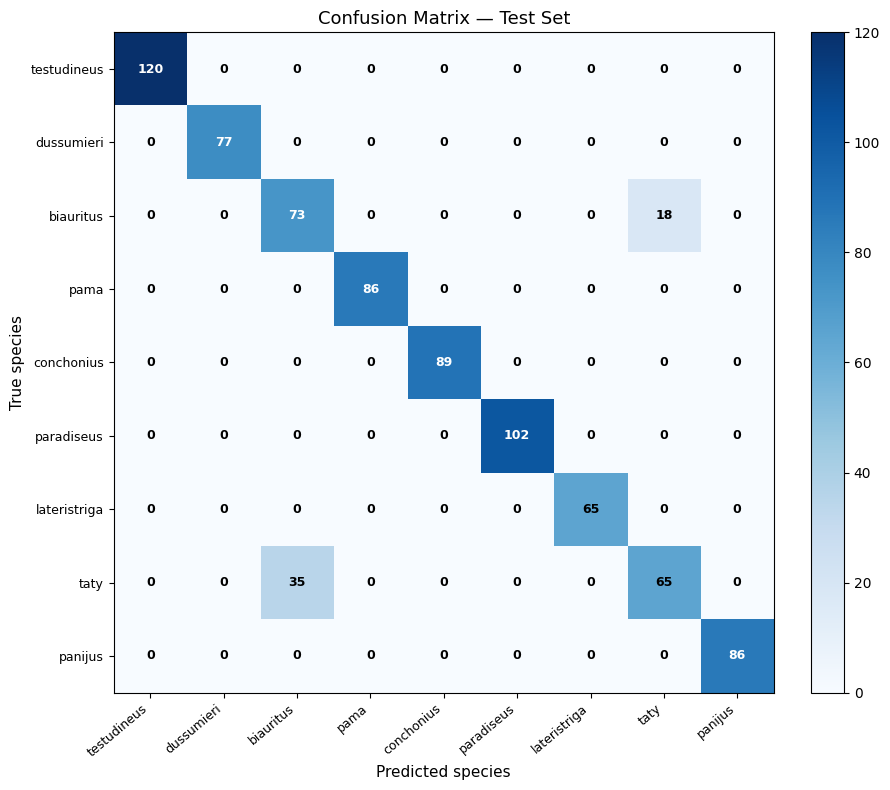

In [14]:
# Visualise the confusion matrix as a heatmap
n_classes = len(label_names)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
short_names = [n.split()[-1] for n in label_names]   # use genus name for brevity
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(short_names, fontsize=9)
ax.set_xlabel('Predicted species', fontsize=11)
ax.set_ylabel('True species', fontsize=11)
ax.set_title('Confusion Matrix — Test Set', fontsize=13)

# Annotate each cell with its count
for i in range(n_classes):
    for j in range(n_classes):
        val = cm[i, j]
        colour = 'white' if val > cm.max() * 0.6 else 'black'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=9, color=colour, fontweight='bold')

plt.tight_layout()
plt.show()

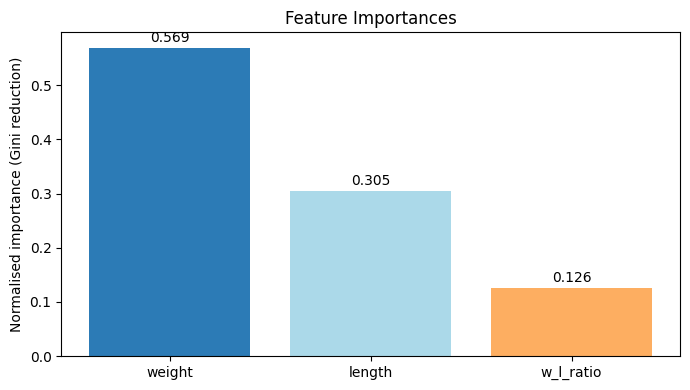

Feature importances:
  weight      : 0.5691
  length      : 0.3046
  w_l_ratio   : 0.1263


In [15]:
# Plot normalised feature importances (proportion of total Gini reduction)
importances = manual_tree.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([feature_cols[i] for i in sorted_idx], importances[sorted_idx],
              color=['#2c7bb6', '#abd9e9', '#fdae61'])
ax.set_ylabel('Normalised importance (Gini reduction)')
ax.set_title('Feature Importances')
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print('Feature importances:')
for i in sorted_idx:
    print(f'  {feature_cols[i]:<12}: {importances[i]:.4f}')

Weight seems to be the most important features in classifying the fishes.

# Normal decision tree

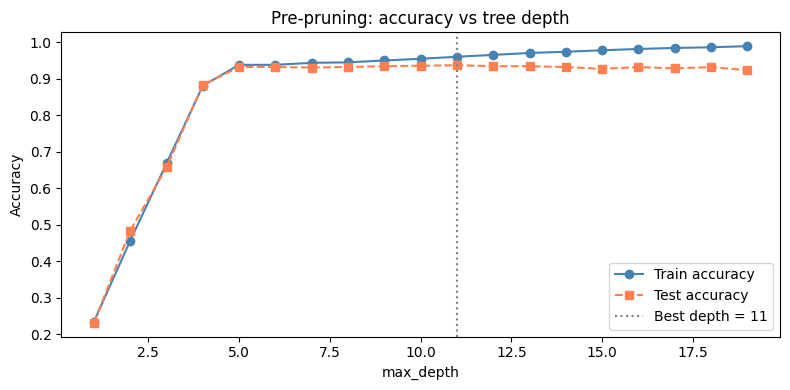

Best max_depth by test accuracy: 11


In [16]:
depths = range(1, 20)
train_accs, test_accs = [], []
 
for d in depths:
    clf = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))
 
plt.figure(figsize=(8, 4))
plt.plot(depths, train_accs, "o-", label="Train accuracy", color="steelblue")
plt.plot(depths, test_accs, "s--", label="Test accuracy", color="coral")
plt.axvline(x=test_accs.index(max(test_accs)) + 1, color="gray",
            linestyle=":", label=f"Best depth = {test_accs.index(max(test_accs)) + 1}")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Pre-pruning: accuracy vs tree depth")
plt.legend()
plt.tight_layout()
plt.show()
 
best_depth = test_accs.index(max(test_accs)) + 1
print(f"Best max_depth by test accuracy: {best_depth}")
 

In [17]:
tree = DecisionTreeClassifier(max_depth=11, min_samples_split=5)
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",11
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [18]:
best_tree = DecisionTreeClassifier(
    criterion="gini", max_depth=best_depth, random_state=42
)
best_tree.fit(X_train, y_train)
y_pred_tree = best_tree.predict(X_test)
 
print(classification_report(y_test, y_pred_tree, target_names=label_names, digits=4))

sklearn_tree_acc = accuracy_score(y_test, y_pred_tree) 


                        precision    recall  f1-score   support

    Anabas testudineus     1.0000    1.0000    1.0000       120
     Coilia dussumieri     1.0000    1.0000    1.0000        77
Otolithoides biauritus     0.7000    0.7692    0.7330        91
     Otolithoides pama     1.0000    1.0000    1.0000        86
     Pethia conchonius     1.0000    1.0000    1.0000        89
  Polynemus paradiseus     1.0000    1.0000    1.0000       102
  Puntius lateristriga     1.0000    1.0000    1.0000        65
        Setipinna taty     0.7692    0.7000    0.7330       100
 Sillaginopsis panijus     1.0000    1.0000    1.0000        86

              accuracy                         0.9375       816
             macro avg     0.9410    0.9410    0.9407       816
          weighted avg     0.9383    0.9375    0.9375       816



The model reached an accuracy of 0.9375, with perfect precision and recall rate for most except Setipinna taty and Otolithoides biauritu as   cases (35 for manual) of taty is labeled biauritus and 21 cases (18 for manual) of biauritus labeled as taty (see matrix below).

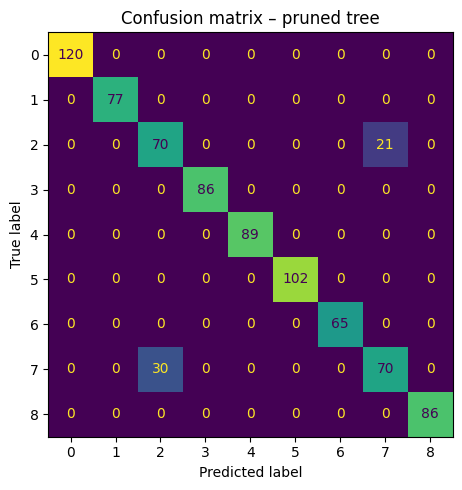

In [19]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tree, ax=ax, colorbar=False
)
ax.set_title("Confusion matrix – pruned tree")
plt.tight_layout()
plt.show()

In [20]:
print(f'Manual tree test accuracy: {manual_tree_acc:.4f}')
print(f"Accuracy of sklearn DecisionTreeClassifier: {sklearn_tree_acc:.4f}")


Manual tree test accuracy: 0.9350
Accuracy of sklearn DecisionTreeClassifier: 0.9375


Both models have similar accuracy scores, with misclassification of the same two cases of the Otolithoides biauritus and the Setipinna taty.

The manual model performs well overall, achieving 93.5% test accuracy compared to sklearn's 93.75%, which validates that the from-scratch implementation is correctly finding optimal splits. 


The two misclassified species, Setipinna taty and Otolithoides biauritus, likely share similar proportions, making them difficult to distinguish using only the given three features Overall, the results suggest that weight and length are highly informative features for fish species classification, with the confusion between two visually similar species being a predictable and explainable outcome given the overlap observed during EDA.